In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, util, morphology, measure, filters
from skimage.color import rgb2gray
from scipy import ndimage

from PIL import Image, ImageDraw

from pathlib import Path

ROOT_DIR = Path.cwd().parent
from scipy.signal import find_peaks

print(ROOT_DIR)

c:\Users\SadovetsRV\Desktop\Work\BMSTU\11_sem\pattern-recognition\Распознавание образов


## Задача 1: Бинаризация, фильтрация, разметка

In [2]:
# Constants
JOURNAL_NUMBER = 4
TARGET_GRAIN_ID = 4 * 5

plt.rcParams['font.family'] = ["Times New Roman"]
plt.rcParams['font.size'] = 16       

# Load image
RICE_PATH = ROOT_DIR / "data/lr2/rice.png"

image = io.imread(RICE_PATH)
print(f"Изображение: {image.shape}, dtype={image.dtype}")

# Приводим к ЧБ виду, далее яркость пикселей Ч-Б изображения к uint8 [0, 255] 
gray_image = rgb2gray(image)
gray_image = util.img_as_ubyte(gray_image) # float64 -> uint8
print(f"Изображение: {gray_image.shape}, dtype={gray_image.dtype}")   # (256, 256) uint8

Изображение: (256, 256, 3), dtype=uint8
Изображение: (256, 256), dtype=uint8


In [3]:
# Размыкание (эрозия+дилатация) по кругу радиусом 15 -> оценка фона изображения
footprint  = morphology.disk(15)                    
background = morphology.opening(gray_image, footprint)

# Вычитаем из изображения фон
image_clean = gray_image.astype(np.int16) - background.astype(np.int16)

# Бинаризация
threshold  = filters.threshold_otsu(image_clean)
binary_image = image_clean > threshold

# Удаляем мелкие объекты (игнор warning)
binary_filtered = morphology.remove_small_objects(binary_image, min_size=30)

C:\Users\SadovetsRV\AppData\Local\Temp\ipykernel_3972\4101212745.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_filtered = morphology.remove_small_objects(binary_image, min_size=30)


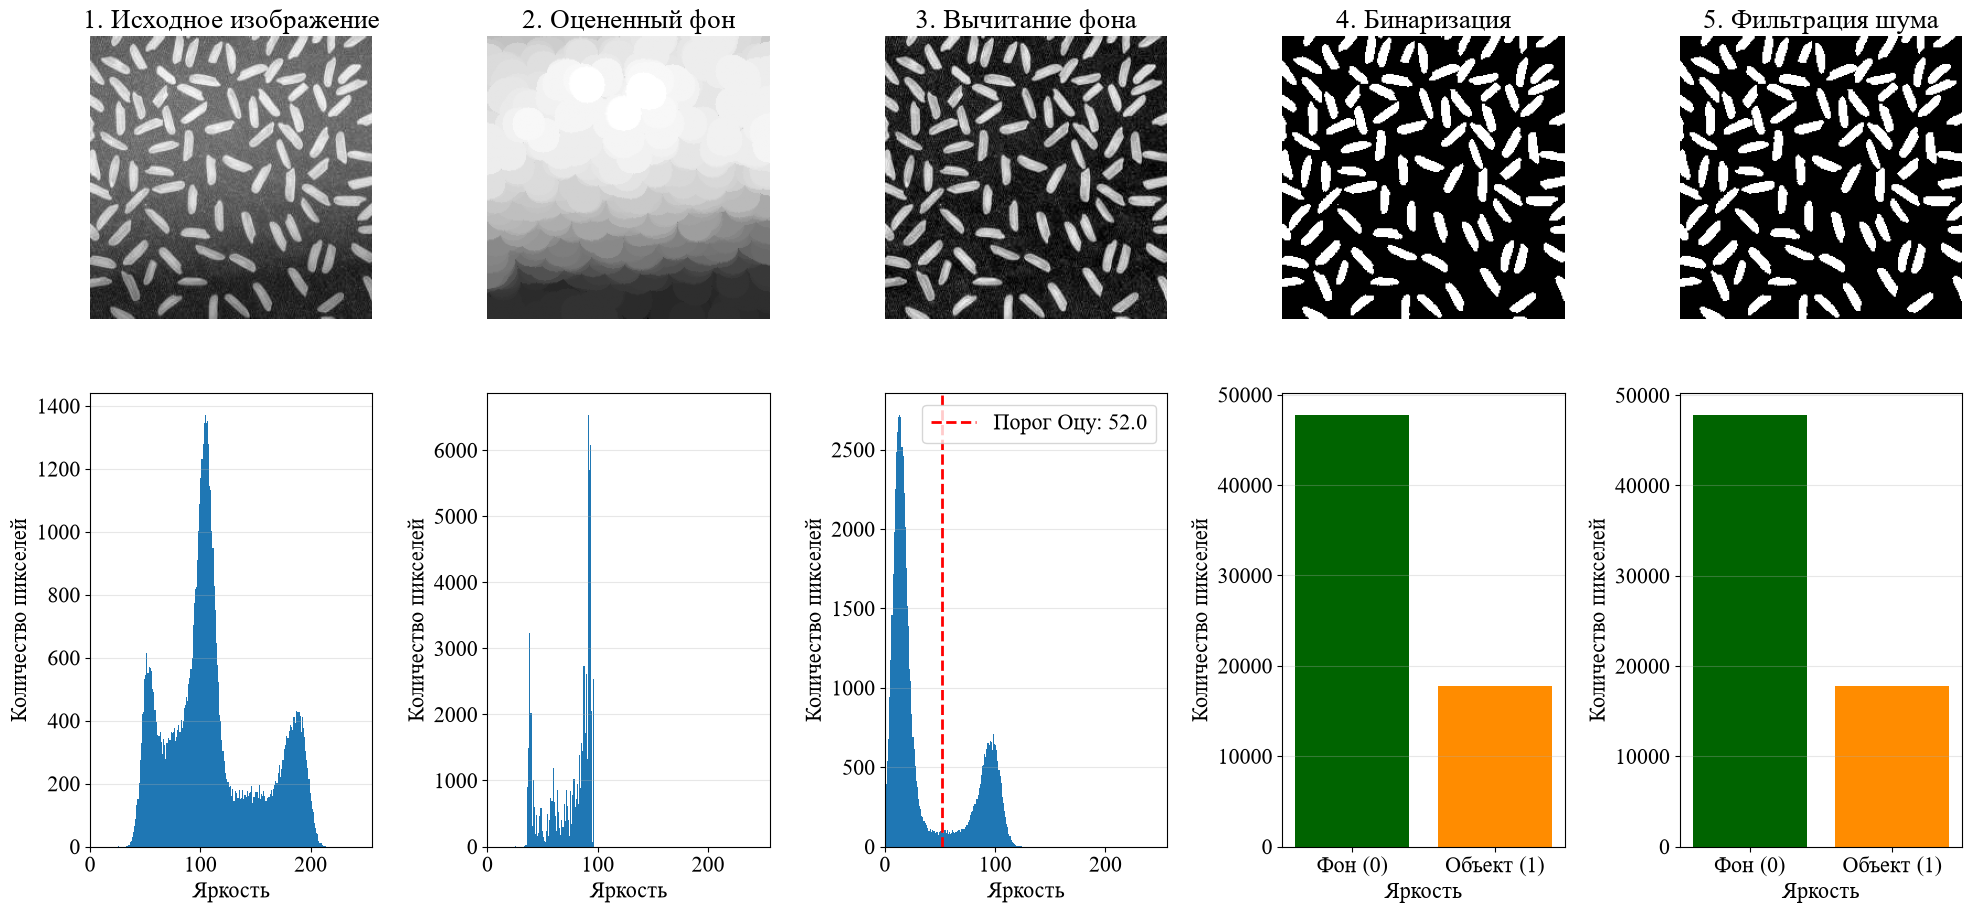

Изображение создано и сохранено как 'rice_processing.png'


In [4]:
fig1, axes1 = plt.subplots(2, 5, figsize=(20, 10))

stages = [
    ('1. Исходное изображение', gray_image, None),
    ('2. Оцененный фон', background, None),
    ('3. Вычитание фона', image_clean, None),
    ('4. Бинаризация', binary_image, threshold),
    ('5. Фильтрация шума', binary_filtered, None),
]

for col, (title, img, thresh) in enumerate(stages):
    axes1[0, col].imshow(img, cmap='gray')
    axes1[0, col].set_title(title)
    axes1[0, col].axis('off')
    
    # Нижний ряд: гистограммы
    if col < 3:  # До бинаризации
        axes1[1, col].hist(img.ravel(), bins=256, range=(0, 256))
        axes1[1, col].set_xlim([0, 256])
        if col == 2:  # Для очищенного изображения отметим порог Оцу
            axes1[1, col].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Порог Оцу: {threshold:.1f}')
            axes1[1, col].legend()
    else:  # Для бинарных изображений
        unique, counts = np.unique(img.astype(int), return_counts=True)
        axes1[1, col].bar(unique, counts, color=['darkgreen', 'darkorange'])
        axes1[1, col].set_xticks([0, 1])
        axes1[1, col].set_xticklabels(['Фон (0)', 'Объект (1)'])
    
    axes1[1, col].set_xlabel('Яркость')
    axes1[1, col].set_ylabel('Количество пикселей')
    axes1[1, col].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

fig1.savefig(ROOT_DIR / "data/lr2/rice_processing.png")
print("Изображение создано и сохранено как 'rice_processing.png'")

In [5]:
# Разметка + подсчёт
labeled_image, total_grains = measure.label(binary_filtered, return_num=True)
print(f"\nВсего зёрен риса на изображении: {total_grains}")

# Ищем рисинку с индексом TARGET_GRAIN_ID
grain_mask = (labeled_image == TARGET_GRAIN_ID)

if np.any(grain_mask):
    isolated_grain = np.where(grain_mask, gray_image, 0)
    print(f"Зерно номер {TARGET_GRAIN_ID} успешно найдено.")
else:
    print(f"Зерно с номером {TARGET_GRAIN_ID} не найдено.")
    isolated_grain = np.zeros_like(gray_image)


# Ищем склееные зёрна
properties = measure.regionprops(labeled_image)
areas = [prop.area for prop in properties]
mean_area = np.mean(areas)

# Склеившиеся зерна: площадь > 1.8 от средней
clumped_threshold = mean_area * 1.8
clumped_grains = [prop.label for prop in properties if prop.area > clumped_threshold]

print(f"Склеившиеся зерна: {len(clumped_grains)} шт.")
print(f"Номера: {clumped_grains}")

clumped_mask = np.isin(labeled_image, clumped_grains)


Всего зёрен риса на изображении: 94
Зерно номер 20 успешно найдено.
Склеившиеся зерна: 3 шт.
Номера: [15, 46, 47]


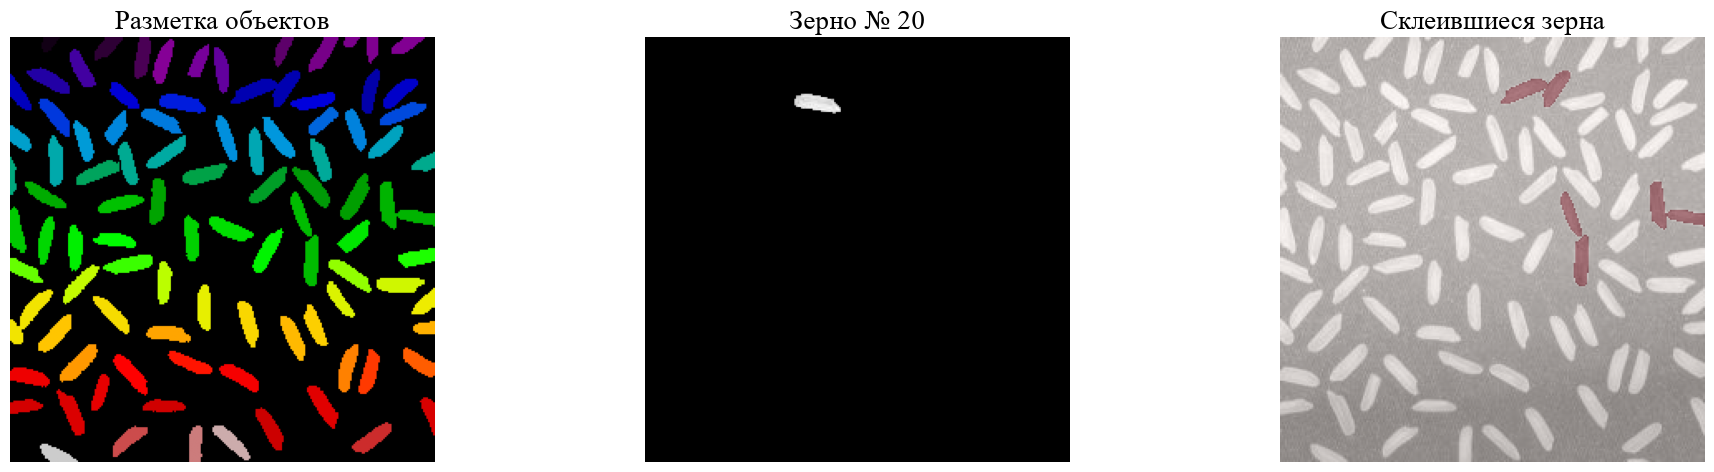

Изображение создано и сохранено как 'rice_glued.png'


In [6]:
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))

axes2[0].imshow(labeled_image, cmap='nipy_spectral')
axes2[0].set_title(f'Разметка объектов')

axes2[1].imshow(isolated_grain, cmap='gray')
axes2[1].set_title(f'Зерно № {TARGET_GRAIN_ID}')

axes2[2].imshow(gray_image, cmap='gray')
axes2[2].imshow(clumped_mask, cmap='Reds', alpha=0.5)
axes2[2].set_title(f'Склеившиеся зерна')

for ax in axes2:
    ax.axis('off')
plt.tight_layout()
plt.show()

fig2.savefig(ROOT_DIR / "data/lr2/rice_glued.png")
print("Изображение создано и сохранено как 'rice_glued.png'")

## Задача 2: Характеристики бинарных объектов

Изображение сгенерировано программно (PIL): правильный пятиугольник, квадрат с четырьмя отверстиями, а также три «лишние» детали (круг, прямоугольник, треугольник)

In [8]:
width, height = 800, 600
image = Image.new('RGB', (width, height), 'white')
draw = ImageDraw.Draw(image)

# Деталь 1: Правильный пятиугольник (слева вверху)
center_pentagon = (150, 150)
radius_pentagon = 80
pentagon_points = []
for i in range(5):
    angle = math.radians(90 + i * 72)  # Начинаем с верхней вершины
    x = center_pentagon[0] + radius_pentagon * math.cos(angle)
    y = center_pentagon[1] - radius_pentagon * math.sin(angle)
    pentagon_points.append((x, y))
draw.polygon(pentagon_points, fill='black')

# Деталь 2: Квадрат с 4 отверстиями (справа вверху)
square_pos = (550, 150)
square_size = 120
draw.rectangle(
    [square_pos[0] - square_size//2, square_pos[1] - square_size//2,
     square_pos[0] + square_size//2, square_pos[1] + square_size//2],
    fill='black'
)

hole_radius = 10
hole_positions = [
    (square_pos[0] - 30, square_pos[1] - 30),
    (square_pos[0] + 30, square_pos[1] - 30),
    (square_pos[0] - 30, square_pos[1] + 30),
    (square_pos[0] + 30, square_pos[1] + 30)
]
 
for pos in hole_positions:
    draw.ellipse(
        [pos[0] - hole_radius, pos[1] - hole_radius,
         pos[0] + hole_radius, pos[1] + hole_radius],
        fill='white'
    )

# Test details
draw.ellipse([100, 400, 250, 550], fill='black') # Круг
draw.rectangle([500, 400, 700, 550], fill='black') # Прямоугольник
triangle_points = [(400, 250), (350, 350), (450, 350)]
draw.polygon(triangle_points, fill='black') # Треугольник

image.save(ROOT_DIR / "data/lr2/test_parts.png")
print("Изображение создано и сохранено как 'test_parts.png'")

Изображение создано и сохранено как 'test_parts.png'


In [ ]:
image_np = np.array(image)

# Предобработка и бинаризация
gray = rgb2gray(image_np)
threshold = filters.threshold_otsu(gray)
binary = (gray < threshold).astype(np.uint8)

# Поиск отверстий
filled_objects = ndimage.binary_fill_holes(binary) # Изображение с заполненными отверстиями
holes_mask = filled_objects.astype(np.uint8) - binary

# Разметка 
labeled_input = measure.label(binary) # Исходное изображение
labeled_filled = measure.label(filled_objects) # Изображение с заполненными отверстиями внутри деталей
labeled_holes, num_holes_total = measure.label(holes_mask, return_num=True) # Изображение, где ТОЛЬКО отверстия внутри деталей

print(f"Всего отверстий: {num_holes_total}")


# Для каждого отверстия смотрим, внутри какой заполненной детали он лежит
holes_count = {}
for h in range(1, num_holes_total + 1):
    r, c = np.argwhere(labeled_holes == h)[0]
    obj = labeled_filled[r, c]
    holes_count[obj] = holes_count.get(obj, 0) + 1


def centroid_profile(obj_mask, n_bins=360):
    """Центроидальный профиль R[phi] выделенного объекта.

    Границы объекта — аналог bwperim() (объект минус его эрозия),
    центр масс — среднее координат точек объекта.
    На выходе — нормированный профиль (деление на среднее значение).
    """
    obj_mask = np.asarray(obj_mask, dtype=bool)

    # Границы объекта (аналог bwperim)
    perim = obj_mask & ~ndimage.binary_erosion(obj_mask)
    ys, xs = np.nonzero(perim)

    # Центр масс объекта — среднее координат его точек
    obj_ys, obj_xs = np.nonzero(obj_mask)
    xc, yc = obj_xs.mean(), obj_ys.mean()

    # Длина и направление радиус-вектора каждой точки границы
    ro = np.hypot(xs - xc, ys - yc)
    fi = np.arctan2(ys - yc, xs - xc)                # [-pi, pi]

    # R[fi]: усредняем ro по угловым бинам, пустые бины — интерполяция
    idx = ((fi + np.pi) / (2 * np.pi) * n_bins).astype(int).clip(0, n_bins - 1)
    R = np.zeros(n_bins)
    cnt = np.zeros(n_bins)
    np.add.at(R, idx, ro)
    np.add.at(cnt, idx, 1)
    nonempty = np.nonzero(cnt)[0]
    R[nonempty] /= cnt[nonempty]
    ext_idx = np.concatenate([nonempty[-1:] - n_bins, nonempty, nonempty[:1] + n_bins])
    ext_val = np.concatenate([R[nonempty][-1:], R[nonempty], R[nonempty][:1]])
    R = np.interp(np.arange(n_bins), ext_idx, ext_val)

    return R / R.mean()


# Признаки объектов: число вершин считаем ПИКАМИ центроидального профиля
features = []
profiles = {}
props_input = measure.regionprops(labeled_input) 

for prop in props_input:

    num_holes = holes_count.get(prop.label, 0)

    # Профиль строим по внешнему контуру детали — отверстия перед этим заполняем
    obj_filled = ndimage.binary_fill_holes(labeled_input == prop.label)
    R = centroid_profile(obj_filled)
    profiles[prop.label] = R

    # Вершины — локальные максимумы профиля.
    # У круга профиль практически плоский (все направления равноправны) — пиков нет.
    peaks, _ = find_peaks(R, prominence=0.05, distance=30)
    num_vertices = len(peaks)

    features.append({
        'label': prop.label,
        'area': prop.area,
        'num_holes': num_holes,
        'num_vertices': num_vertices
    })
    print(f"Деталь {prop.label}: вершин={num_vertices}, отверстий={num_holes}, площадь={prop.area}")


# Закраска
result = image_np.copy()

for feat in features:
    mask = (labeled_input == feat['label'])

    if feat['num_vertices'] == 5 and feat['num_holes'] == 0:
        result[mask] = [255, 0, 0]       # красный — пятиугольник
        print(f"\n✓ Пятиугольник → деталь {feat['label']}")

    if feat['num_holes'] == 4:
        result[mask] = [0, 255, 0]
        result[holes_mask.astype(bool) & mask] = [255, 255, 255] 
        filled_mask = (labeled_filled == feat['label'])
        result[holes_mask.astype(bool) & filled_mask] = [255, 255, 255]
        print(f"✓ 4 отверстия → деталь {feat['label']}")


Всего отверстий: 4
Деталь 1: вершин=5, отверстий=0, площадь=15436.0
Деталь 2: вершин=4, отверстий=4, площадь=13245.0
Деталь 3: вершин=3, отверстий=0, площадь=5101.0
Деталь 4: вершин=0, отверстий=0, площадь=17881.0
Деталь 5: вершин=4, отверстий=0, площадь=30351.0

✓ Пятиугольник → деталь 1
✓ 4 отверстия → деталь 2


### Центроидальные профили деталей

Количество вершин детали определяется числом **пиков центроидального профиля** R[φ] (зависимость длины радиус-вектора из центра масс к границе от направления φ). У пятиугольника — 5 пиков, у квадрата и прямоугольника — по 4, у треугольника — 3. У круга все направления равноправны, профиль практически плоский, поэтому пиков нет.

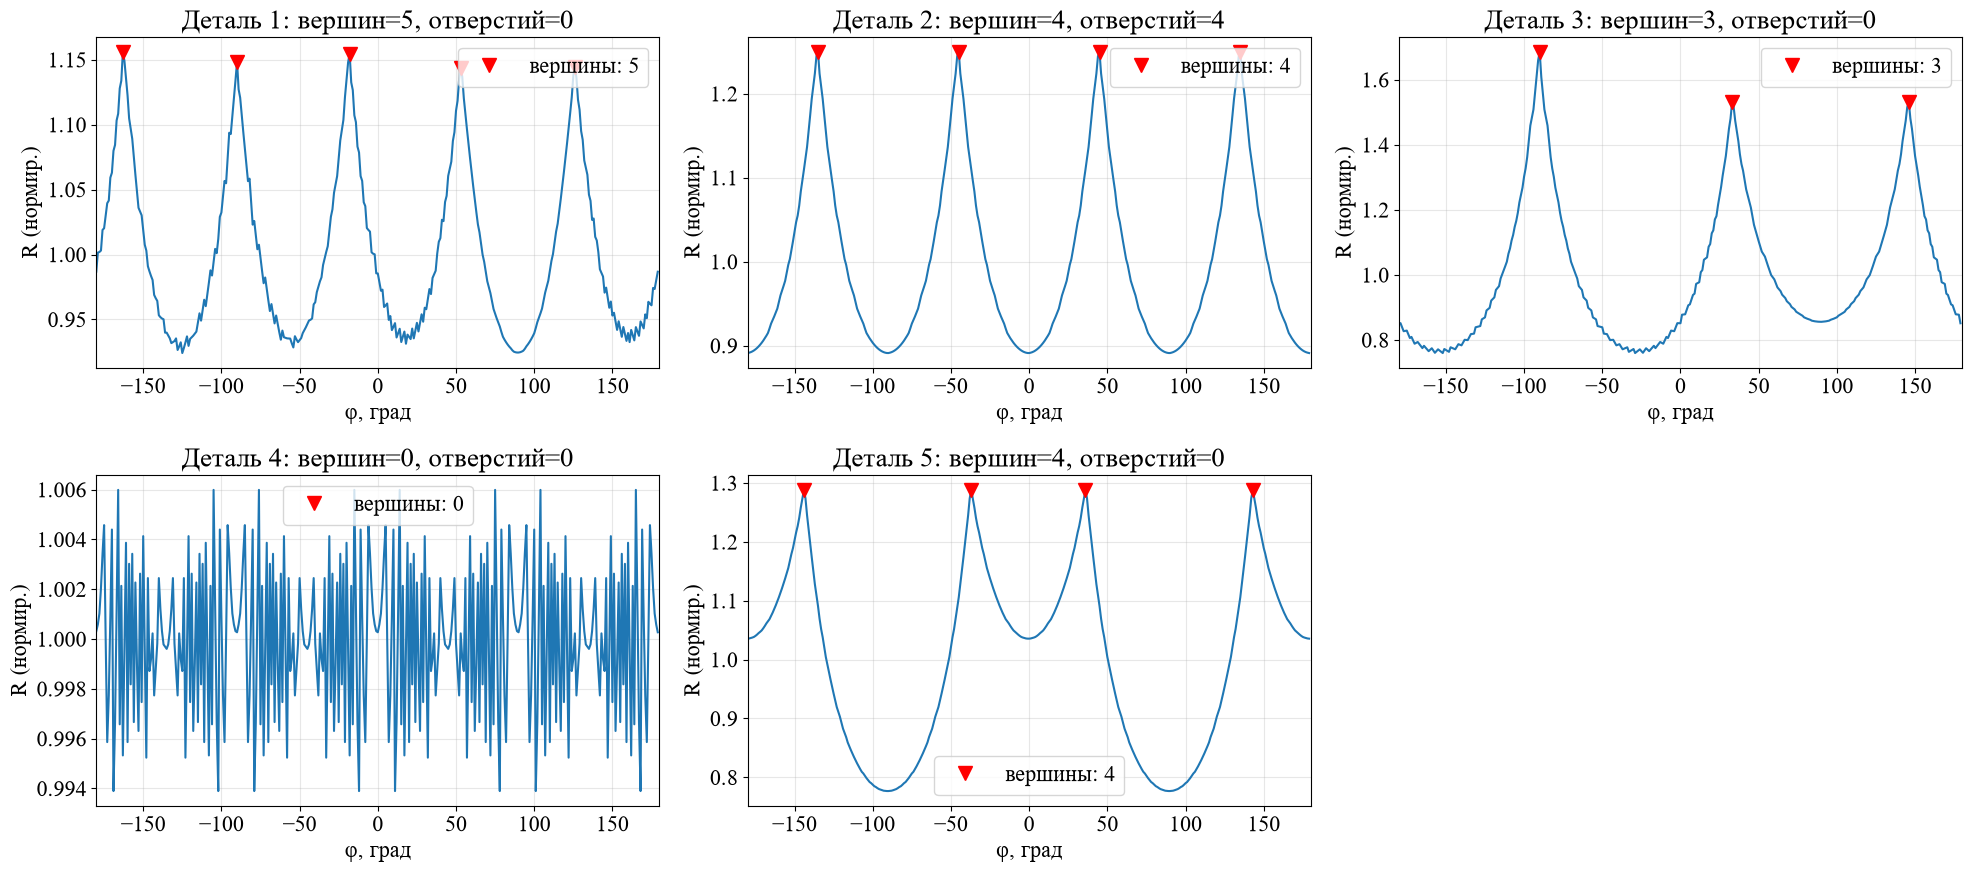

Профили сохранены как 'centroid_profiles.png'


In [10]:
fig3, axes3 = plt.subplots(2, 3, figsize=(20, 9))
axes3 = axes3.ravel()
phi = np.linspace(-180, 180, 360, endpoint=False)

for ax, feat in zip(axes3, features):
    R = profiles[feat['label']]
    peaks, _ = find_peaks(R, prominence=0.05, distance=30)
    ax.plot(phi, R, linewidth=1.5)
    ax.plot(phi[peaks], R[peaks], 'rv', markersize=10, label=f'вершины: {len(peaks)}')
    ax.set_title(f"Деталь {feat['label']}: вершин={feat['num_vertices']}, отверстий={feat['num_holes']}")
    ax.set_xlabel('φ, град')
    ax.set_ylabel('R (нормир.)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(-180, 180)

axes3[-1].axis('off')
plt.tight_layout()
plt.show()

fig3.savefig(ROOT_DIR / "data/lr2/centroid_profiles.png")
print("Профили сохранены как 'centroid_profiles.png'")

### Инвариантность центроидального профиля

Меняем масштаб пятиугольника на ±25 % (аналог imresize) и поворачиваем его на ±10° (аналог imrotate). **Масштаб** после нормировки профиля на среднее значение **не изменяет** форму профиля — профиль масштабно-инвариантен. **Поворот** лишь **сдвигает** профиль по оси φ на угол поворота — форма пиков сохраняется, поэтому число вершин остаётся прежним.

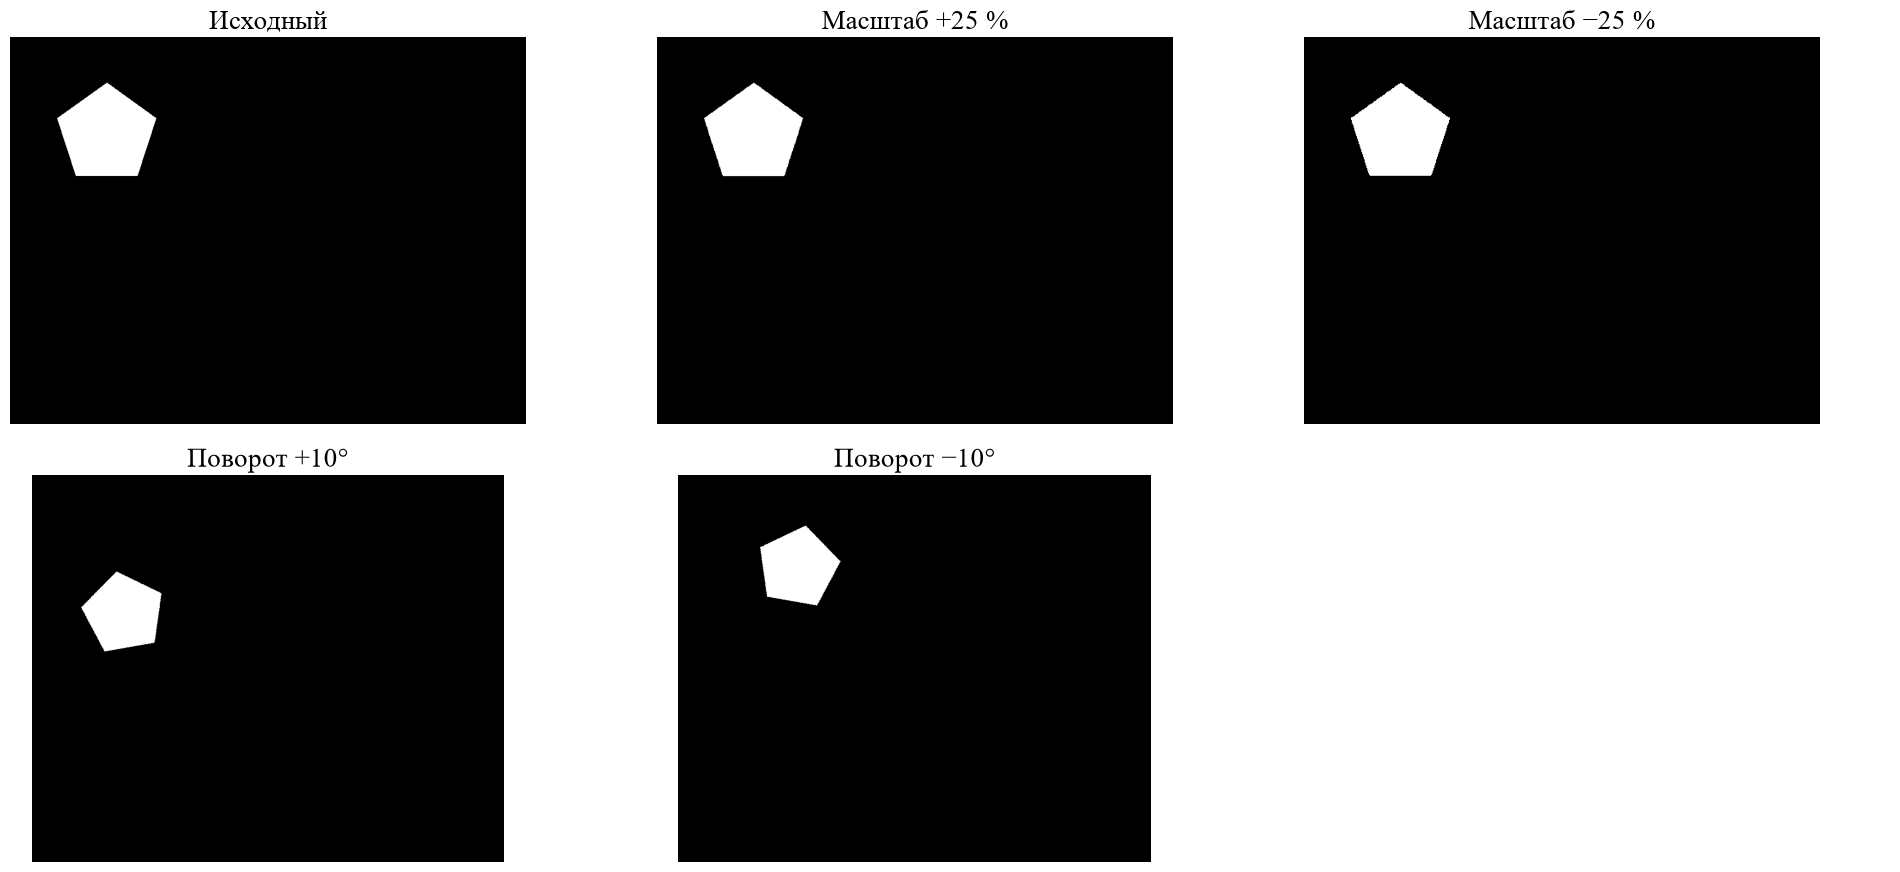

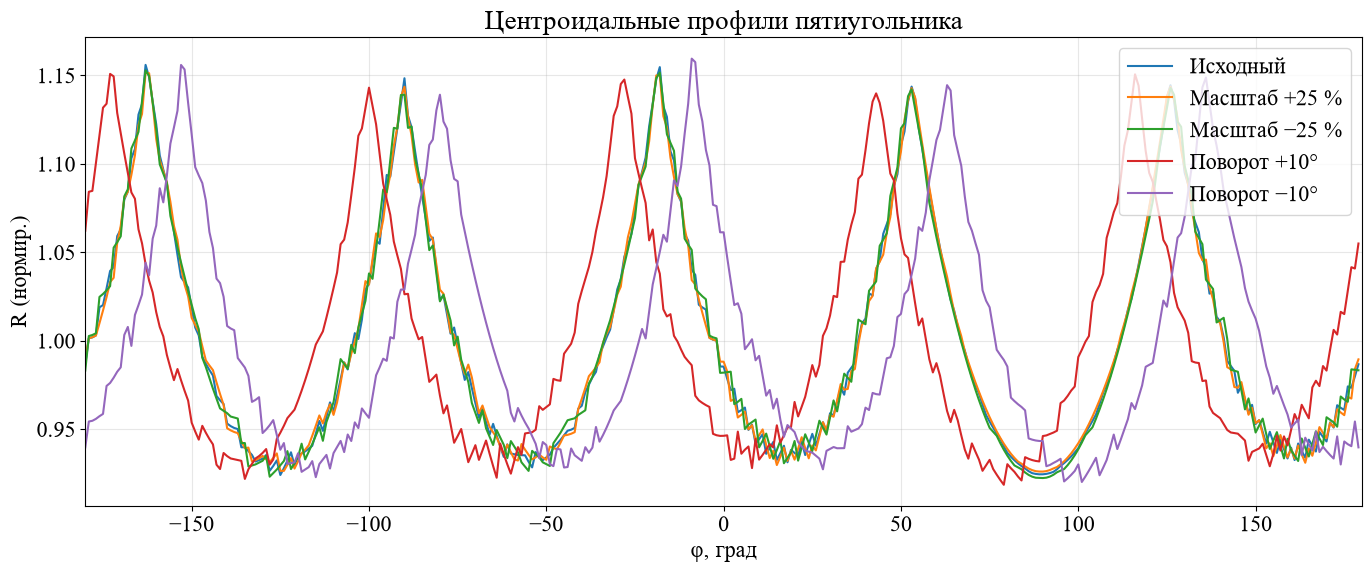

Сохранено: 'pentagon_variants.png', 'centroid_invariance.png'


In [11]:
from skimage.transform import resize, rotate

# Маска найденного пятиугольника
pentagon_label = next(f['label'] for f in features if f['num_vertices'] == 5 and f['num_holes'] == 0)
penta_mask = (labeled_input == pentagon_label).astype(float)
h, w = penta_mask.shape

# У нас объекты — белые (1) на чёрном (0) фоне, поэтому инвертировать, как в MATLAB, не нужно:
# при повороте фон заполняется нулями, что и так соответствует чёрному фону.
variants = {
    'Исходный': penta_mask,
    'Масштаб +25 %': resize(penta_mask, (round(h * 1.25), round(w * 1.25)), preserve_range=True, anti_aliasing=True) > 0.5,
    'Масштаб −25 %': resize(penta_mask, (round(h * 0.75), round(w * 0.75)), preserve_range=True, anti_aliasing=True) > 0.5,
    'Поворот +10°': rotate(penta_mask, 10, resize=True, preserve_range=True) > 0.5,
    'Поворот −10°': rotate(penta_mask, -10, resize=True, preserve_range=True) > 0.5,
}

fig4, axes4 = plt.subplots(2, 3, figsize=(20, 9))
axes4 = axes4.ravel()

for ax, (name, m) in zip(axes4, variants.items()):
    ax.imshow(m, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

axes4[-1].axis('off')
plt.tight_layout()

fig5, ax5 = plt.subplots(figsize=(14, 6))
for name, m in variants.items():
    ax5.plot(phi, centroid_profile(m), linewidth=1.5, label=name)
ax5.set_xlabel('φ, град')
ax5.set_ylabel('R (нормир.)')
ax5.set_title('Центроидальные профили пятиугольника')
ax5.legend()
ax5.grid(alpha=0.3)
ax5.set_xlim(-180, 180)
plt.tight_layout()
plt.show()

fig4.savefig(ROOT_DIR / "data/lr2/pentagon_variants.png")
fig5.savefig(ROOT_DIR / "data/lr2/centroid_invariance.png")
print("Сохранено: 'pentagon_variants.png', 'centroid_invariance.png'")

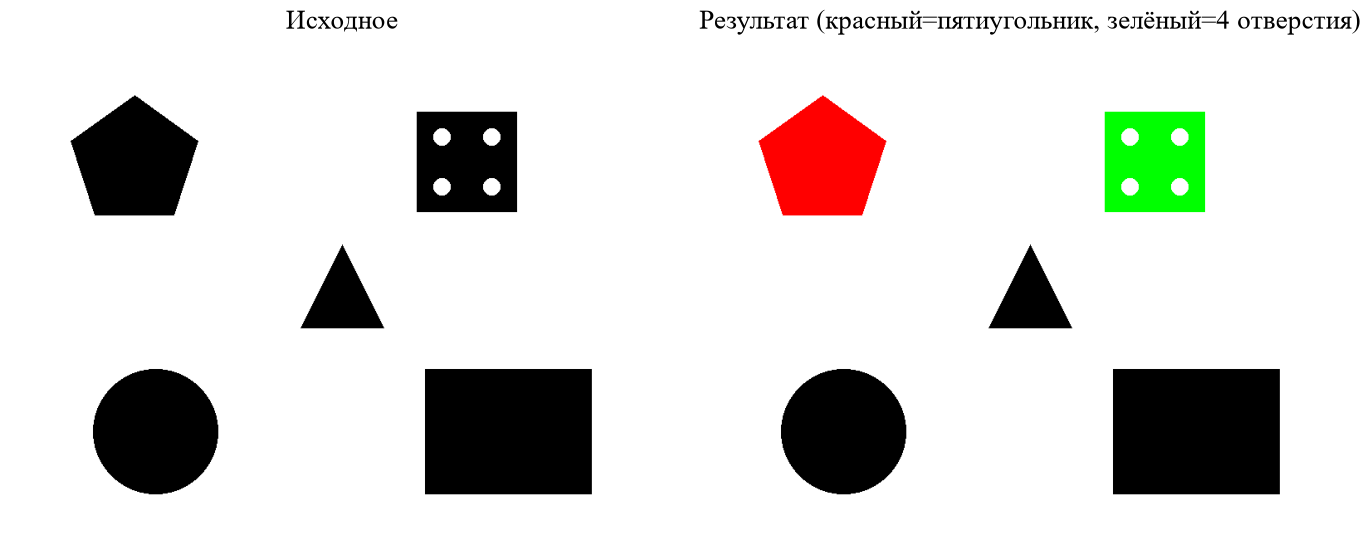


Результат сохранён как 'test_parts_result.png'


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(image_np)
ax[0].set_title('Исходное')
ax[0].axis('off')
ax[1].imshow(result)
ax[1].set_title('Результат (красный=пятиугольник, зелёный=4 отверстия)')
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Сохранение результата
result_pil = Image.fromarray(result)
result_pil.save(ROOT_DIR / "data/lr2/test_parts_result.png")
print("\nРезультат сохранён как 'test_parts_result.png'")